<a href="https://colab.research.google.com/github/sevaraa127-cloud/KI_Medizin/blob/main/SoSe26_Wiederholung_Lektion_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## NumPy Arrays

At its core, a NumPy array is a high-performance, grid-like data structure. While it looks a bit like a standard Python list, it’s built for speed and mathematical efficiency.

To use NumPy, you first need to import it. The convention is to alias it as `np`.

Example:

In [ ]:
import numpy as np

# Creating a 1D array from a list
my_list = [10, 20, 30, 40]
my_array = np.array(my_list)

print(f"Array: {my_array}")
print(f"Shape: {my_array.shape}") # Tells you the dimensions of your numpy array
print(f"Data Type: {my_array.dtype}") # Tells you the type of data stored

Array: [10 20 30 40]
Shape: (4,)
Data Type: int64


The shape of an array is the number of elements in each dimension. Reshaping adds or removes the dimensions.

In [ ]:
import numpy as np

my_array = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

newarr = my_array.reshape(4, 3) # 4 rows, 3 columns

#Exercise: Reshape your array so it has only 1 column
newarr = my_array.reshape(___, ___)

print(newarr)

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


## Machine Learning

1. The Mean (The Average)

The Mean is the most common way to find an average. You add everything up and share it out equally.

2. The Median (The Middle)

The Median is the literal middle point of your data.

3. The Mode (The Most Frequent)

The Mode is the number that shows up most often.

Example:

Imagine a room with five people whose ages are: 2, 2, 5, 7, 34.

In [ ]:
import numpy as np
from scipy import stats # Mode is often handled by scipy

ages = np.array([2, 2, 5, 7, 34])

print(np.mean(ages))   # 10.0
print(np.median(ages)) # 5.0
print(stats.mode(ages)) # Mode: 2

10.0
5.0
ModeResult(mode=np.int64(2), count=np.int64(2))


4. Standard Deviation (The "Spread")

Standard Deviation measures how much your numbers "deviate" from the average (mean).

5. Percentile (The "Rank")

A percentile tells you the percentage of data points that fall at or below a certain value.

Let's look at the test scores of 10 students.

In [ ]:
import numpy as np

scores = np.array([55, 60, 65, 70, 75, 80, 85, 90, 95, 100])

# Calculate Standard Deviation
sd = np.std(scores) # Result: ~14.36

# Calculate the 75th Percentile
p75 = np.percentile(scores, 75) # Result: 88.75
print(f"{sd:.2f}", "and", p75)

14.36 and 88.75


## Regression

Regression is a way to find the relationship between variables so you can predict a numerical outcome.

If "Mean" tells you what happened in the past, "Regression" tries to guess what will happen in the future based on a pattern.

Imagine you are plotting points on a graph. Regression is the math used to draw a single straight line (or curve) that gets as close as possible to all those points.

  * The Input ($x$): What you already know (e.g., Square footage of a house).
  
  * The Output ($y$): What you want to predict (e.g., The price of that house).
  
  
If you know the square footage ($x$) and the price ($y$) of 100 houses, Regression finds the pattern. Once you have that pattern, you can plug in a new house size, and the line will tell you the estimated price.

Types of Regression (The Big Two)

1. Linear Regression: Finding a straight-line relationship (like the example above).

2. Logistic Regression: (Despite the name, this is for classification). It predicts the probability of something happening (e.g., Will it rain? Yes or No?).

## Linear Regression

Imagine a study where doctors are tracking how a new blood pressure medication affects a patient's Systolic Blood Pressure (SBP).

  * The Input ($x$): Dosage of medication (in mg).
  * The Output ($y$): Reduction in Blood Pressure (in mmHg).

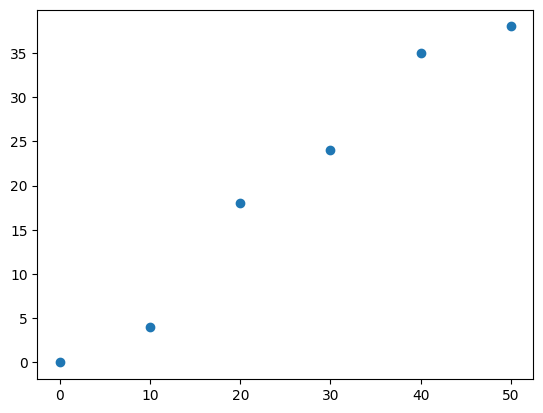

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dosage = np.array([0, 10, 20, 30, 40, 50])
reduction = np.array([0, 4, 18, 24, 35, 38])

plt.scatter(dosage, reduction)
plt.show()

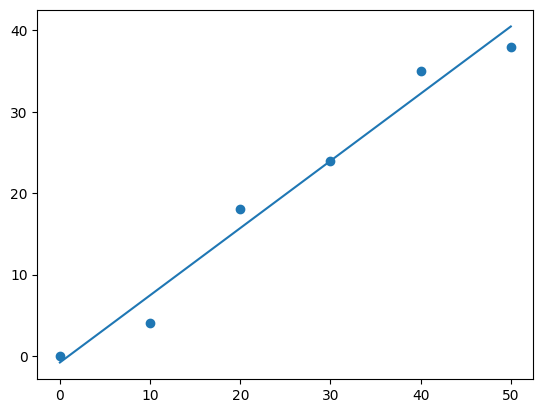

11.576190476190476


In [ ]:
from scipy import stats

slope, intercept, r, p, std_err = stats.linregress(dosage, reduction)

def myfunc(dosage):
  return slope * dosage + intercept # It's a formula for our regression line: y = mx + b, where m = slope, b = intercept

mymodel = list(map(myfunc, dosage)) #It takes your function (myfunc) and applies it to every number in your dosage list.

plt.scatter(dosage, reduction)
plt.plot(dosage, mymodel)
plt.show()

# Predict the reduction of blood pressure based on the dosage of 55 mg, 15 mg and 25 mg
print(myfunc(15))

```python
slope, intercept, r, p, std_err = stats.linregress(dosage, reduction)
```
This line calculates the relationship between your dosage and the reduction.

It returns five variables:

  * `slope`: How much the reduction changes for every 1mg of dosage.
  * `intercept`: The starting point (where the line hits the y-axis).
  * `r`: (Correlation Coefficient) Tells you how strong the relationship is.
    * $1.0$ is a perfect line;
    * $0$ is total chaos.
  * `p`: (P-value) It tells you if the result is statistically significant ($p < 0.05$ usually means the drug actually works and isn't just a coincidence).
  * `std_err`: The "Standard Error," which tells you how much the slope might vary.

In [ ]:
print(r) # The coefficient of correlation

0.9869844815071811


## Multiple Regression

Multiple regression is like linear regression, but with more than one independent value, meaning that we try to predict a value based on two or more variables.

### Predicting House Prices

To keep the code clean and simple, we'll use `sklearn` (Scikit-Learn), which is the industry standard for this.

Variables:
  * $x_1$: Square Footage
  * $x_2$: Number of Bedrooms
  * $y$: Price (What we want to predict)

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Prepare your data
# [Square Footage, Bedrooms]
X = np.array([
    [1500, 3],
    [2000, 3],
    [2500, 4],
    [3000, 4],
    [3500, 5]
])

# Price of the houses
y = np.array([250000, 300000, 400000, 450000, 550000])

# 2. Create the Regression Object
regr = LinearRegression()

# 3. Train the model (Find the relationship)
regr.fit(X, y)
# This is the "learning" step. The computer calculates the "weights" for each feature. It figures out:
# How much does 1 extra square foot add to the price?
# How much does 1 extra bedroom add to the price?

# 4. Predict the price of a house with 2200 sq ft and 3 bedrooms
predicted_price = regr.predict([[2200, 3]])

print(f"Predicted Price: ${predicted_price[0]:,.2f}")

Predicted Price: $320,000.00
[  100. 50000.]


In [ ]:
print(regr.coef_)
# It would give you two numbers.
# Coefficient 1: The price increase per square foot.
# Coefficient 2: The price increase per bedroom.

[  100. 50000.]


### Exercise

You have data from 5 patients who underwent a specific procedure. You want to see how their age and the amount of Vitamin C they took affected how many days it took them to recover.

The Data:

* Features ($X$): [Age, Dosage in mg]
* Target ($y$): Days to Recover

In [ ]:
import numpy as np
from _____.______ import ______ #Ergänzen

# 1. Create the Data Arrays
# X contains [Age, Dosage]
X = np.array([
    [25, 100],
    [30, 200],
    [45, 100],
    [50, 300],
    [60, 200]
])

# y contains the Recovery Days
y = np.array([5, 4, 9, 6, 10])

# 2. Build and Train the Model
___ = ___
___.___(___, ___)

# 3. Find the Coefficients and print them
# These numbers tell us how much Age and Dosage impact the result
___(___.___)

# 4. Predict and print for a new patient: Age 55, Dosage 150
___

## Train/Test

If you show your model all the data, it might simply "memorize" the answers (we call this Overfitting). To see if the model actually learned the underlying pattern, we hide a portion of the data during training and use it later to test the model's accuracy.

The Concept
* Training Set: Usually 70-80% of your data. The model uses this to learn the relationship between $X$ and $y$.
* Testing Set: The remaining 20-30%. The model has never seen this data. We ask it to make predictions and then compare those predictions to the actual "hidden" answers.

Let's predict a car's Price based on its Mileage and Age.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 1. A larger dataset
# Features: [Mileage, Age]
X = np.array([
    [5000, 1], [15000, 2], [25000, 3], [35000, 4], [45000, 5],
    [55000, 6], [65000, 7], [75000, 8], [85000, 9], [95000, 10]
])

# Target: Price
y = np.array([35000, 32000, 29000, 26000, 24000, 21000, 18000, 15000, 13000, 10000])

# 2. Split the data
# test_size=0.2 means 20% goes to testing (2 cars), 80% to training (8 cars)
# random_state is a seed so you get the same "random" split every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the model using ONLY the training data
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Test the model using the hidden testing data
predictions = model.predict(X_test)

# 5. See how we did
print(f"Actual Prices:    {y_test}")
print(f"Predicted Prices: {predictions.round(2)}")

# 6. Calculate the Mean Absolute Error (Average mistake in dollars)
mae = metrics.mean_absolute_error(y_test, predictions)
print(f"\nOn average, our predictions are off by: ${mae:.2f}")

Actual Prices:    [13000 32000]
Predicted Prices: [12534.48 31965.52]

On average, our predictions are off by: $250.00


### Exercise

You are analyzing how Sleep Hours and Exercise Minutes predict a person's "Wellness Score" (0–100).

The Data:
* Features ($X$): [Sleep Hours, Exercise Minutes]
* Target ($y$): Wellness Score



In [ ]:
import numpy as np

X = np.array([[5, 20], [7, 30], [8, 60], [6, 10], [9, 45], [5, 45], [8, 10], [7, 60]])
y = np.array([55, 72, 88, 50, 92, 65, 70, 85])

Your Exercise Task:
1. Split the Data: Use train_test_split with a test_size of 0.2 (20%) and a random_state of 1.
2. Train: Create a LinearRegression model and fit it using your training data.
3. Predict: Generate predictions for your test data.
4. Evaluate Accuracy:
  * Calculate and print the Mean Absolute Error (MAE).

## R-Squared and Cross-Validation

R-squared tells you how well your model fits the data you have, while Cross-Validation tells you if your model will actually work on data you haven't seen yet.

1. R-Squared ($R^2$): The "Percentage of Logic"

Think of $R^2$ as a score that tells you how much of the "wiggle" (variance) in your data is explained by your model.

The Scale:

It usually ranges from 0 to 1 (or 0% to 100%).

  * 0.0: Your model explains nothing.
  * 1.0: Your model explains everything. It hits every single point perfectly.
  
The Reality: In medicine or social sciences, an $R^2$ of 0.6 or 0.7 is often considered quite good. In physics, you might expect 0.99.

$$R^2 = 1 - \frac{\text{The errors your model makes}}{\text{The total variation in the data}}$$

If you are trying to predict a student's grade, and you only know their "Study Hours," you might get an $R^2$ of 0.5. This means 50% of the grade is explained by studying. The other 50% is "unexplained" (maybe sleep, stress, or natural talent).

2. Cross-Validation: The "Stress Test"

A single Train/Test Split can sometimes be lucky or unlucky. What if the 20% of data you chose for testing happened to be the easiest points to predict? Your accuracy would look great, but it would be a lie.

Cross-Validation (specifically K-Fold) solves this by rotating the test set.

How K-Fold (e.g., K=5) works:

1. Split your data into 5 equal parts (folds).

  * Round 1: Use Fold 1 for testing, Folds 2-5 for training.

  * Round 2: Use Fold 2 for testing, Folds 1, 3, 4, 5 for training.

  * ...Repeat until every fold has been the "test set" once.

2. The Result: You average the scores from all 5 rounds to get a "True" accuracy.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Sample Data
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.array([2, 4, 5, 4, 6, 8, 10, 9, 11, 12])

model = LinearRegression()

# Perform 5-Fold Cross-Validation
# We use 'r2' as our scoring metric
scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print(f"Scores for each fold: {scores}")
print(f"Average R-Squared: {scores.mean():.2f}")

Scores for each fold: [ 0.53054138 -4.61149691  0.77243828 -3.68055556  0.91326531]
Average R-Squared: -1.22


If your model is better than the average, $R^2$ is Positive.

If your model is exactly as good as guessing the average, $R^2$ is Zero.

If your model is worse than just guessing the average, $R^2$ is Negative.

### Exercise:

1. Import the necessary tools from sklearn (LinearRegression, train_test_split, metrics, and cross_val_score).
2. Format the $X$ data as a 2D array (using .reshape(-1, 1)).
3. Split the data using a test_size=0.3.Train the model.
4. Calculate the $R^2$ score.Validate using a 3-fold Cross-Validation (since we have 10 points, 3 or 5 folds work best).

The Variables
1. X (Hours): This is the Independent Variable. It represents the time that has passed since the patient received a single dose of the medication.

2. y (Concentration mg/L): This is the Dependent Variable. It is the amount of the drug measured in the patient's blood (milligrams per liter) at each hour.

In [ ]:
import numpy as np
from sklearn.linear_model import ___
from sklearn.model_selection import ___, ___
from sklearn import ___

# 1. Prepare the Lab Data
A = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
X = ___.___(___, ___)
y = np.array([92, 84, 75, 68, 60, 52, 44, 35, 28, 20])

# 2. Split the data (70% Train, 30% Test)
X_train, X_test, y_train, y_test = ___(X, y, ___=___, random_state=42)

# 3. Build and Fit the Model
___ = ___()
___.___(___, ___)

# 4. Predict and Calculate R-Squared
predictions = ___.___(___)
r2_score = metrics.r2_score(y_test, predictions)

# 5. Perform 3-Fold Cross-Validation
# We use 3 folds here because the dataset is small
cv_scores = ___(model, X, y, cv=___)

# Results
print(f"Single Split R2: {r2_score:.5f}")
print(f"Average Cross-Validation Score: {cv_scores.mean():.5f}")

Single Split R2: 0.99984
Average Cross-Validation Score: 0.99542
Drug Clearance Rate: -8.00 mg/L per hour


## Ridge Regression

In standard regression, the model wants to get the $R^2$ as high as possible by fitting the training data perfectly. This often leads to Overfitting, where the model learns the "noise" or random spikes in your data rather than the actual trend.

Imagine you are training a model. Standard regression is like a student who memorizes every single word of a textbook—they pass the practice exam (Training) with 100%, but fail the real exam (Testing) because they didn't understand the general concepts.

Ridge Regression adds a penalty to the size of the coefficients (the weights of your variables). It says: "I want you to fit the data, but I'm going to penalize you for having very large, sensitive coefficients."

This "shrinks" the coefficients toward zero, making the model less sensitive to small fluctuations in the data.

The most important part of Ridge Regression is a value called Alpha.
* $\alpha = 0$: This is just standard Linear Regression (no penalty).
* Small $\alpha$: A light touch; reduces overfitting slightly.
* Large $\alpha$: A heavy penalty; coefficients get very small, potentially making the model too simple (Underfitting).

This example focuses on a classic medical prediction: Recovery Days after surgery based on Age, Body Mass Index (BMI), and Blood Protein Levels.

In this scenario, we use Ridge to ensure that no single variable (like a slightly noisy BMI reading) dominates the prediction.

In [ ]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Features: [Age, BMI, Protein Level]
X = np.array([
    [25, 22.5, 7.2],
    [30, 28.0, 6.8],
    [45, 24.1, 8.1],
    [50, 31.5, 6.5],
    [60, 26.3, 7.9]
])

# Target: Recovery Days
y = np.array([5, 8, 7, 12, 11])

# 1. Scale the data (Crucial for Ridge!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply Ridge with a moderate Alpha
ridge = Ridge(alpha=1.5)
ridge.fit(X_scaled, y)

# 3. View the Results
print(f"Intercept (Baseline Days): {ridge.intercept_:.2f}") # It is the value of y when all your features (X) are equal to zero.
print(f"Coefficients (Age, BMI, Protein): {ridge.coef_.round(3)}")

Intercept (Baseline Days): 8.60
Coefficients (Age, BMI, Protein): [ 1.345  1.112 -0.286]


## Lasso

If Ridge is the "gentle shrinker," then Lasso (Least Absolute Shrinkage and Selection Operator) is the "brutal filter."

While both are used to prevent overfitting, Lasso has a unique "superpower": it can force coefficients to become exactly zero.

The Core Difference: Feature Selection
* Ridge (L2): Shrinks coefficients so they are very small, but they rarely reach zero. Every variable stays in the model.

* Lasso (L1): Shrinks coefficients all the way to zero if the variable isn't useful enough. It effectively deletes useless features for you.

Analogy: If you are packing a suitcase for a trip:

* Ridge tells you to bring everything but pack smaller, lighter versions of each item.

* Lasso looks at your 5 pairs of shoes and says, "You only need the sneakers. Leave the other 4 at home."